# Backtest — Polymarket Implied EV Lead Strategy

**Hypothesis**: Polymarket Implied EV leads NYMEX CL futures prices by **~2 hours** (peak cross-correlation r = +0.386 at lag +2h).  
**Strategy**: At each 2-hour bar, compute the EV z-score signal. Because EV leads by exactly 1 bar (2h), the backtester's built-in 1-bar execution delay naturally models the real-world edge — the signal fires at *t*, the trade executes at *t + 2h*.

| Signal | Condition | Rationale |
|--------|-----------|---------- |
| **BUY  +1** | Z-score > +1σ | EV > Futures by >1σ → crowd expects futures to rise |
| **SELL −1** | Z-score < −1σ | EV < Futures by >1σ → exit / avoid long |
| **HOLD  0** | \|Z\| ≤ 1σ    | No significant divergence |

In [3]:
# ── Path setup ────────────────────────────────────────────────────────────────
import sys
from pathlib import Path

ROOT_NB = Path.cwd().parent          # project root  (notebooks/ → ../ )
sys.path.insert(0, str(ROOT_NB))     # makes 'config' importable
DATA_DIR = ROOT_NB / "data" / "raw"
OUT_DIR  = DATA_DIR / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Standard imports ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy  as np
import pandas as pd
import matplotlib.pyplot  as plt
import matplotlib.dates   as mdates
import matplotlib.ticker  as mticker
import matplotlib.gridspec as gridspec

from scipy.interpolate import PchipInterpolator
from scipy.stats       import lognorm, norm

# ── Config constants (mirrors execution/backtester.py defaults) ───────────────
from config import INITIAL_CAPITAL, RISK_PER_TRADE_PCT, COMMISSION_PCT
from config import STOP_LOSS_PCT, TAKE_PROFIT_PCT, BACKTEST_PERIODS_PER_YEAR

# ── Colour palette ────────────────────────────────────────────────────────────
P = {
    "buy":      "#16A34A",
    "sell":     "#DC2626",
    "ev":       "#DC2626",
    "futures":  "#16A34A",
    "equity":   "#2563EB",
    "bh":       "#6B7280",
    "ci":       "#C7D2FE",
    "zscore":   "#7C3AED",
}

plt.rcParams.update({
    "figure.dpi":        130,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "font.family":       "DejaVu Sans",
})
plt.rcParams["grid.alpha"] = 0.28

print(f"✓  setup complete — project root: {ROOT_NB}")
print(f"   INITIAL_CAPITAL={INITIAL_CAPITAL:,}  RISK_PER_TRADE={RISK_PER_TRADE_PCT}%  COMMISSION={COMMISSION_PCT}%")


✓  setup complete — project root: /Users/hukaiyu/Desktop/Fin/Quantihack-ADA
   INITIAL_CAPITAL=10,000  RISK_PER_TRADE=1.0%  COMMISSION=0.1%


In [4]:
# ── run_backtest — inlined from execution/backtester.py ──────────────────────
# (execution/backtester.py uses float | None syntax which requires Python 3.10+;
#  this cell replicates the exact same logic using Optional for Python 3.9.)

from dataclasses import dataclass
from typing import Optional


@dataclass
class _Position:
    entry_price:     float
    shares:          float
    stop_loss_pct:   Optional[float]
    take_profit_pct: Optional[float]

    def current_value(self, price: float) -> float:
        return self.shares * price

    def should_stop_loss(self, price: float) -> bool:
        if self.stop_loss_pct is None:
            return False
        return price <= self.entry_price * (1 - self.stop_loss_pct / 100)

    def should_take_profit(self, price: float) -> bool:
        if self.take_profit_pct is None:
            return False
        return price >= self.entry_price * (1 + self.take_profit_pct / 100)


def _calculate_metrics(equity_curve, initial_capital, periods_per_year):
    values = pd.Series([e["value"] for e in equity_curve])
    total_return  = (values.iloc[-1] - initial_capital) / initial_capital * 100
    daily_returns = values.pct_change().dropna()
    sharpe = ((daily_returns.mean() / daily_returns.std()) * np.sqrt(periods_per_year)
              if daily_returns.std() != 0 else 0)
    rolling_max  = values.cummax()
    max_drawdown = ((values - rolling_max) / rolling_max).min() * 100
    return {
        "total_return_pct": round(total_return,  2),
        "sharpe_ratio":      round(sharpe,        2),
        "max_drawdown_pct":  round(max_drawdown,  2),
        "final_value":       round(values.iloc[-1], 2),
    }


def run_backtest(prices: pd.Series, signals: pd.Series) -> dict:
    """
    Mirrors execution/backtester.py::run_backtest exactly.
    prices:  price series indexed by timestamp  (NYMEX close)
    signals: {+1 BUY, -1 SELL, 0 HOLD} aligned with prices
    Returns: dict with keys — metrics, equity_curve, trades, final_capital
    """
    df = pd.DataFrame({"close": prices, "signal": signals}).dropna().sort_index()
    # 1-bar execution lag — act on the *previous* bar's signal (no lookahead)
    df["signal_prev"] = df["signal"].shift(1).fillna(0)

    capital      = INITIAL_CAPITAL
    position     = None
    current_trade = None
    trades       = []
    equity_curve = []

    for date, row in df.iterrows():
        price  = row["close"]
        signal = row["signal_prev"]

        if position and current_trade:
            exit_reason = None
            if position.should_stop_loss(price):
                exit_reason = "stop_loss"
            elif position.should_take_profit(price):
                exit_reason = "take_profit"
            elif signal == -1:
                exit_reason = "signal"

            if exit_reason:
                proceeds   = position.current_value(price)
                commission = proceeds * (COMMISSION_PCT / 100)
                capital   += proceeds - commission
                current_trade["exit_date"]  = str(date)
                current_trade["exit_price"] = round(price, 6)
                current_trade["pnl"]        = round(
                    proceeds - position.entry_price * position.shares, 6)
                current_trade["reason"]     = exit_reason
                trades.append(current_trade)
                position, current_trade = None, None

        if signal == 1 and position is None:
            amount_to_invest       = capital * (RISK_PER_TRADE_PCT / 100)
            commission             = amount_to_invest * (COMMISSION_PCT / 100)
            amount_after_commission = amount_to_invest - commission
            shares                 = amount_after_commission / price
            capital               -= amount_to_invest
            position = _Position(price, shares, STOP_LOSS_PCT, TAKE_PROFIT_PCT)
            current_trade = {
                "entry_date":  str(date),
                "entry_price": round(price,  6),
                "shares":      round(shares, 6),
            }

        portfolio_value = capital + (position.current_value(price) if position else 0)
        equity_curve.append({"date": str(date), "value": round(portfolio_value, 6)})

    metrics = _calculate_metrics(equity_curve, INITIAL_CAPITAL,
                                 BACKTEST_PERIODS_PER_YEAR)
    if len(df) >= 2:
        metrics["buy_hold_return_pct"] = round(
            (df["close"].iloc[-1] / df["close"].iloc[0] - 1) * 100, 2)
    else:
        metrics["buy_hold_return_pct"] = 0.0
    metrics["n_trades"] = len(trades)
    return {"metrics": metrics, "equity_curve": equity_curve,
            "trades": trades, "final_capital": round(capital, 2)}


print("✓  run_backtest ready (Python 3.9-compatible inline)")


✓  run_backtest ready (Python 3.9-compatible inline)


In [8]:
# ── Load raw data ─────────────────────────────────────────────────────────────
pm_raw = pd.read_csv(DATA_DIR / "polymarket" / "crude_oil_prices.csv",
                     parse_dates=["timestamp"])
# Normalise column name (CSV uses 'strike'; helper functions expect 'strike_val')
if "strike_val" not in pm_raw.columns and "strike" in pm_raw.columns:
    pm_raw = pm_raw.rename(columns={"strike": "strike_val"})
# Strip leading '$' from strike values (e.g. '$100' → 100)
pm_raw["strike_val"] = pd.to_numeric(
    pm_raw["strike_val"].astype(str).str.replace("$", "", regex=False),
    errors="coerce",
)
pm_raw = pm_raw.dropna(subset=["strike_val", "price", "timestamp"])
pm_raw["price"] = pm_raw["price"].clip(1e-4, 1 - 1e-4)

nymex = pd.read_csv(DATA_DIR / "nymex" / "CL_F_30m.csv",
                    parse_dates=["timestamp"])
nymex_1h = (nymex.set_index("timestamp")["close"]
                 .resample("1h").last()
                 .ffill())

print(f"Polymarket:  {len(pm_raw):,} rows  "
      f"({pm_raw['timestamp'].min().date()} → {pm_raw['timestamp'].max().date()})")
print(f"NYMEX 1h:    {len(nymex_1h):,} bars  "
      f"({nymex_1h.index.min().date()} → {nymex_1h.index.max().date()})")


Polymarket:  69,342 rows  (2026-02-28 → 2026-03-28)
NYMEX 1h:    622 bars  (2026-03-01 → 2026-03-27)


In [9]:
# ── Helper functions (same pipeline as true_price.ipynb) ──────────────────────

def build_cdf_snapshot(pm_raw, t):
    past = pm_raw[pm_raw["timestamp"] <= t]
    if len(past) < 2:
        return pd.DataFrame(columns=["strike", "cdf_value"])
    latest = (past.sort_values("timestamp")
                  .groupby(["strike_val", "direction"], as_index=False)
                  .last()[["strike_val", "direction", "price"]])
    rows = []
    for _, row in latest.iterrows():
        p     = float(row["price"])
        cdf_v = (1.0 - p) if row["direction"] == "up" else p
        rows.append({"strike": float(row["strike_val"]), "cdf_value": cdf_v})
    df = (pd.DataFrame(rows)
            .groupby("strike", as_index=False)["cdf_value"].mean()
            .sort_values("strike").reset_index(drop=True))
    df["cdf_value"] = df["cdf_value"].clip(1e-4, 1 - 1e-4)
    df["cdf_value"] = np.maximum.accumulate(df["cdf_value"].values)
    return df


def fit_smooth_cdf(df_cdf, x_min=35.0, x_max=230.0, n_grid=1000):
    K     = df_cdf["strike"].values.astype(float)
    F_obs = df_cdf["cdf_value"].values.astype(float)
    valid = (F_obs > 0.02) & (F_obs < 0.98)
    if valid.sum() >= 3:
        z_vals   = norm.ppf(F_obs[valid])
        coeffs   = np.polyfit(np.log(K[valid]), z_vals, 1)
        sigma_ln = max(1.0 / coeffs[0], 0.01)
        mu_ln    = -coeffs[1] * sigma_ln
    else:
        mu_ln, sigma_ln = np.log(80.0), 0.25
    K_lo  = max(1.0, K[0]  * 0.40)
    K_hi  = K[-1] * 1.60
    pchip = PchipInterpolator(
        np.concatenate([[K_lo], K, [K_hi]]),
        np.concatenate([[0.0],  F_obs, [1.0]]),
        extrapolate=False,
    )
    x_grid    = np.linspace(x_min, x_max, n_grid)
    cdf_pchip = pchip(x_grid)
    cdf_ln    = lognorm.cdf(x_grid, s=sigma_ln, scale=np.exp(mu_ln))
    cdf_s     = np.clip(np.maximum.accumulate(
                    np.where(np.isnan(cdf_pchip), cdf_ln, cdf_pchip)), 0.0, 1.0)
    dx        = x_grid[1] - x_grid[0]
    pdf_s     = np.maximum(np.gradient(cdf_s, dx), 0.0)
    area      = np.trapz(pdf_s, x_grid)
    if area > 1e-10:
        pdf_s /= area
    ev     = float(np.trapz(x_grid * pdf_s, x_grid))
    mode   = float(x_grid[np.argmax(pdf_s)])
    cumsum = np.cumsum(pdf_s) * dx
    ci_lo  = float(x_grid[np.searchsorted(cumsum, 0.05)])
    ci_hi  = float(x_grid[np.searchsorted(cumsum, 0.95)])
    return {"ev": ev, "mode": mode, "ci_90": (ci_lo, ci_hi)}


def alpha_signal(ev, futures_price, gap_history=None, z_threshold=1.0):
    basis_gap = ev - futures_price
    if gap_history and len(gap_history) >= 5:
        arr     = np.array(gap_history[-500:], dtype=float)
        sig_g   = arr.std(ddof=1)
        z_score = (basis_gap - arr.mean()) / sig_g if sig_g > 1e-8 else 0.0
    else:
        z_score = 0.0
    signal = 1 if z_score > z_threshold else (-1 if z_score < -z_threshold else 0)
    return {"basis_gap": basis_gap, "z_score": z_score, "signal": signal}


def compute_rolling_ev(pm_raw, nymex_1h, freq="2h", min_strikes=6, z_threshold=1.0):
    timestamps = pd.date_range(
        start=pm_raw["timestamp"].min().ceil(freq),
        end=pm_raw["timestamp"].max().floor(freq),
        freq=freq,
    )
    results, gap_history = [], []
    for t in timestamps:
        if t < nymex_1h.index.min():
            continue
        fx = float(nymex_1h.asof(t))
        if np.isnan(fx):
            continue
        snap = build_cdf_snapshot(pm_raw, t)
        if len(snap) < min_strikes:
            continue
        try:
            res = fit_smooth_cdf(snap)
        except Exception:
            continue
        sig = alpha_signal(res["ev"], fx, gap_history=gap_history,
                           z_threshold=z_threshold)
        gap_history.append(sig["basis_gap"])
        results.append({
            "timestamp": t,
            "pm_ev":     res["ev"],
            "nymex":     fx,
            "basis":     sig["basis_gap"],
            "z_score":   sig["z_score"],
            "signal":    sig["signal"],
            "ci_lo":     res["ci_90"][0],
            "ci_hi":     res["ci_90"][1],
        })
    return pd.DataFrame(results).set_index("timestamp")


print("✓  helper functions defined")

✓  helper functions defined


In [10]:
# ── Compute rolling EV + signals ──────────────────────────────────────────────
print("Computing rolling EV (2-hour frequency) …")
df_roll = compute_rolling_ev(pm_raw, nymex_1h, freq="2h", z_threshold=1.0)
print(f"  {len(df_roll)} snapshots  "
      f"{df_roll.index.min().date()} → {df_roll.index.max().date()}")
print(f"  Signal counts: "
      f"BUY={( df_roll['signal']==1).sum()}  "
      f"SELL={(df_roll['signal']==-1).sum()}  "
      f"HOLD={(df_roll['signal']==0).sum()}")

Computing rolling EV (2-hour frequency) …
  319 snapshots  2026-03-02 → 2026-03-28
  Signal counts: BUY=38  SELL=110  HOLD=171


---
## Backtest — Baseline (Z-threshold = 1.0σ)

The backtester executes the *previous bar's* signal at the *current bar's* price.  
Since our bars are 2 h apart, this is equivalent to acting on the EV signal **2 hours after it fires** — exactly matching the measured lead time.

In [11]:
# ── Run backtest ──────────────────────────────────────────────────────────────
prices  = df_roll["nymex"].rename("close")      # NYMEX CL futures price series
signals = df_roll["signal"]                      # +1 BUY / -1 SELL / 0 HOLD

result  = run_backtest(prices, signals)
metrics = result["metrics"]
trades  = pd.DataFrame(result["trades"])
eq_raw  = result["equity_curve"]
equity  = pd.DataFrame(eq_raw)
equity["date"] = pd.to_datetime(equity["date"])
equity = equity.set_index("date")

# ── Buy-and-hold baseline ─────────────────────────────────────────────────────
bh_curve = INITIAL_CAPITAL * (prices / prices.iloc[0])

# ── Print metrics ─────────────────────────────────────────────────────────────
print("=" * 52)
print("  EV-LEAD STRATEGY — BACKTEST RESULTS")
print("=" * 52)
print(f"  Total Return   : {metrics['total_return_pct']:+.2f}%")
print(f"  Buy & Hold     : {metrics['buy_hold_return_pct']:+.2f}%")
print(f"  Sharpe Ratio   : {metrics['sharpe_ratio']:.3f}")
print(f"  Max Drawdown   : {metrics['max_drawdown_pct']:.2f}%")
print(f"  Final Capital  : ${metrics['final_value']:,.2f}")
print(f"  # Trades       : {metrics['n_trades']}")
if not trades.empty:
    wins     = (trades["pnl"] > 0).sum()
    win_rate = wins / len(trades) * 100
    avg_pnl  = trades["pnl"].mean()
    print(f"  Win Rate       : {win_rate:.1f}%  ({wins}/{len(trades)})")
    print(f"  Avg Trade PnL  : ${avg_pnl:+.4f}")
print("=" * 52)

  EV-LEAD STRATEGY — BACKTEST RESULTS
  Total Return   : +0.10%
  Buy & Hold     : +40.94%
  Sharpe Ratio   : 0.300
  Max Drawdown   : -0.39%
  Final Capital  : $10,010.48
  # Trades       : 2
  Win Rate       : 100.0%  (2/2)
  Avg Trade PnL  : $+5.4477


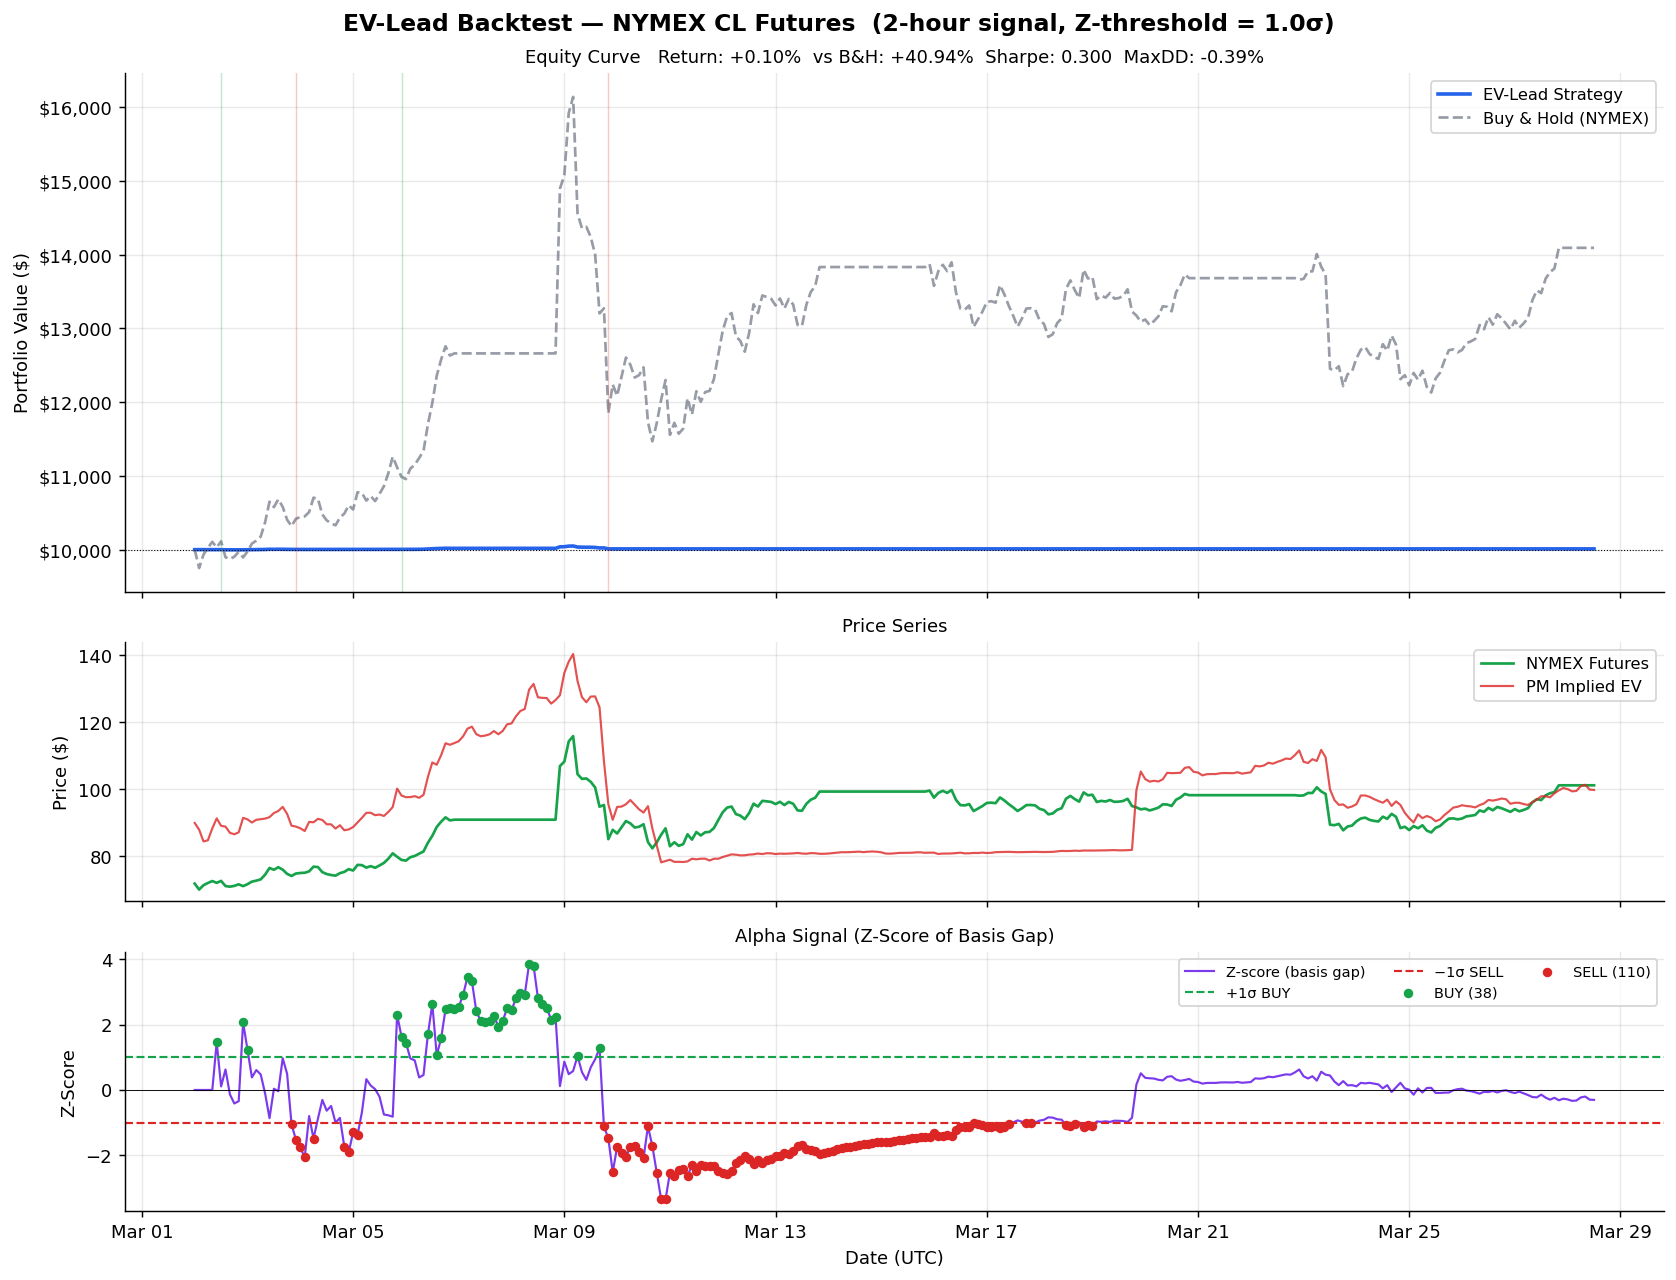

Saved → outputs/backtest_ev_lead_equity.png


In [12]:
# ── Plot 1: Equity Curve ──────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True,
                          gridspec_kw={"height_ratios": [3, 1.5, 1.5]})
fig.suptitle("EV-Lead Backtest — NYMEX CL Futures  (2-hour signal, Z-threshold = 1.0σ)",
             fontsize=13, fontweight="bold")

# Panel 1: equity vs buy-and-hold
ax1 = axes[0]
ax1.plot(equity.index, equity["value"],
         color=P["equity"], lw=2.0, label="EV-Lead Strategy")
ax1.plot(bh_curve.index, bh_curve.values,
         color=P["bh"], lw=1.5, ls="--", alpha=0.7, label="Buy & Hold (NYMEX)")
ax1.axhline(INITIAL_CAPITAL, color="black", lw=0.6, ls=":")
# Mark trade entries and exits
if not trades.empty:
    trades["entry_date"] = pd.to_datetime(trades["entry_date"])
    trades["exit_date"]  = pd.to_datetime(trades["exit_date"])
    for _, tr in trades.iterrows():
        ax1.axvline(tr["entry_date"], color=P["buy"],  alpha=0.25, lw=0.8)
        ax1.axvline(tr["exit_date"],  color=P["sell"], alpha=0.25, lw=0.8)
ax1.set_ylabel("Portfolio Value ($)", fontsize=10)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax1.legend(fontsize=9)
ax1.set_title(f"Equity Curve   Return: {metrics['total_return_pct']:+.2f}%  "
              f"vs B&H: {metrics['buy_hold_return_pct']:+.2f}%  "
              f"Sharpe: {metrics['sharpe_ratio']:.3f}  "
              f"MaxDD: {metrics['max_drawdown_pct']:.2f}%",
              fontsize=10)

# Panel 2: NYMEX price + EV overlay
ax2 = axes[1]
ax2.plot(df_roll.index, df_roll["nymex"],
         color=P["futures"], lw=1.5, label="NYMEX Futures")
ax2.plot(df_roll.index, df_roll["pm_ev"],
         color=P["ev"], lw=1.2, alpha=0.8, label="PM Implied EV")
ax2.set_ylabel("Price ($)", fontsize=10)
ax2.legend(fontsize=9)
ax2.set_title("Price Series", fontsize=10)

# Panel 3: Z-score with buy/sell thresholds
ax3 = axes[2]
ax3.plot(df_roll.index, df_roll["z_score"],
         color=P["zscore"], lw=1.2, label="Z-score (basis gap)")
ax3.axhline( 1.0, color=P["buy"],  lw=1.2, ls="--", label="+1σ BUY")
ax3.axhline(-1.0, color=P["sell"], lw=1.2, ls="--", label="−1σ SELL")
ax3.axhline( 0.0, color="black",   lw=0.5)
buy_idx  = df_roll[df_roll["signal"] ==  1].index
sell_idx = df_roll[df_roll["signal"] == -1].index
ax3.scatter(buy_idx,  df_roll.loc[buy_idx,  "z_score"],
            color=P["buy"],  s=18, zorder=4, label=f"BUY ({len(buy_idx)})")
ax3.scatter(sell_idx, df_roll.loc[sell_idx, "z_score"],
            color=P["sell"], s=18, zorder=4, label=f"SELL ({len(sell_idx)})")
ax3.set_ylabel("Z-Score", fontsize=10)
ax3.set_xlabel("Date (UTC)", fontsize=10)
ax3.legend(fontsize=8, ncol=3)
ax3.set_title("Alpha Signal (Z-Score of Basis Gap)", fontsize=10)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

plt.tight_layout()
out = OUT_DIR / "backtest_ev_lead_equity.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out.relative_to(DATA_DIR)}")

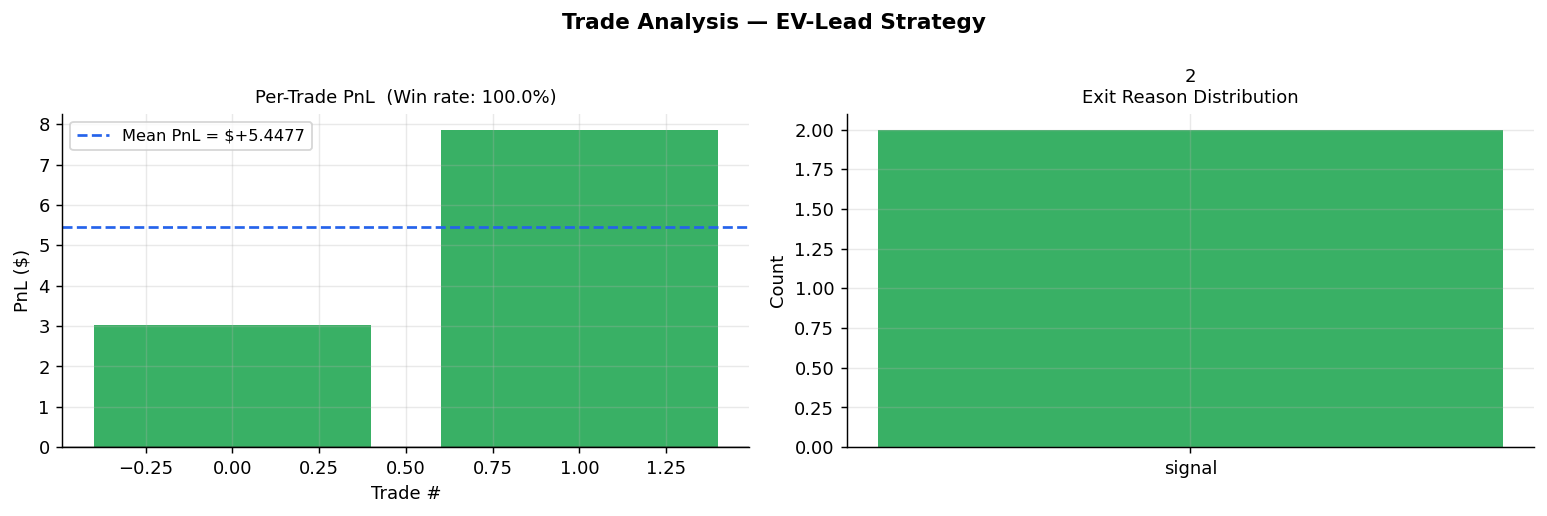

Saved → outputs/backtest_ev_lead_trades.png


In [13]:
# ── Plot 2: Trade PnL distribution ───────────────────────────────────────────
if trades.empty:
    print("No trades to analyse.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle("Trade Analysis — EV-Lead Strategy", fontsize=12, fontweight="bold")

    # Left: PnL histogram
    ax = axes[0]
    colors = [P["buy"] if p > 0 else P["sell"] for p in trades["pnl"]]
    ax.bar(range(len(trades)), trades["pnl"].values, color=colors, alpha=0.85)
    ax.axhline(0, color="black", lw=0.8)
    ax.axhline(trades["pnl"].mean(), color=P["equity"], lw=1.5, ls="--",
               label=f"Mean PnL = ${trades['pnl'].mean():+.4f}")
    ax.set_xlabel("Trade #", fontsize=10)
    ax.set_ylabel("PnL ($)", fontsize=10)
    ax.set_title(f"Per-Trade PnL  (Win rate: {(trades['pnl']>0).mean()*100:.1f}%)",
                 fontsize=10)
    ax.legend(fontsize=9)

    # Right: exit reasons
    ax2 = axes[1]
    reason_counts = trades["reason"].value_counts()
    rc = [P["buy"] if r == "signal" else P["sell"] if r == "stop_loss" else P["bh"]
          for r in reason_counts.index]
    ax2.bar(reason_counts.index, reason_counts.values, color=rc, alpha=0.85)
    ax2.set_title("Exit Reason Distribution", fontsize=10)
    ax2.set_ylabel("Count", fontsize=10)
    for i, (label, cnt) in enumerate(reason_counts.items()):
        ax2.text(i, cnt + 0.3, str(cnt), ha="center", fontsize=10)

    plt.tight_layout()
    out = OUT_DIR / "backtest_ev_lead_trades.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {out.relative_to(DATA_DIR)}")

In [14]:
# ── Z-threshold sensitivity sweep ────────────────────────────────────────────
# Re-run the full pipeline at each threshold, then compare key metrics.
thresholds = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]
sweep_rows = []

for z in thresholds:
    df_z = compute_rolling_ev(pm_raw, nymex_1h, freq="2h", z_threshold=z)
    r    = run_backtest(df_z["nymex"].rename("close"), df_z["signal"])
    m    = r["metrics"]
    trd  = pd.DataFrame(r["trades"])
    win_rate = (trd["pnl"] > 0).mean() * 100 if not trd.empty else float("nan")
    sweep_rows.append({
        "Z-threshold":  z,
        "Total Return %": m["total_return_pct"],
        "B&H Return %":   m["buy_hold_return_pct"],
        "Sharpe":         m["sharpe_ratio"],
        "Max DD %":        m["max_drawdown_pct"],
        "# Trades":        m["n_trades"],
        "Win Rate %":      round(win_rate, 1),
    })
    print(f"  Z={z:.2f}  return={m['total_return_pct']:+.2f}%  "
          f"sharpe={m['sharpe_ratio']:.3f}  trades={m['n_trades']}")

sweep_df = pd.DataFrame(sweep_rows).set_index("Z-threshold")
print("\n", sweep_df.to_string())

  Z=0.50  return=+0.19%  sharpe=0.510  trades=3
  Z=0.75  return=+0.12%  sharpe=0.340  trades=3
  Z=1.00  return=+0.10%  sharpe=0.300  trades=2
  Z=1.25  return=+0.14%  sharpe=0.400  trades=2
  Z=1.50  return=+0.14%  sharpe=0.400  trades=2
  Z=2.00  return=+0.15%  sharpe=0.420  trades=2

              Total Return %  B&H Return %  Sharpe  Max DD %  # Trades  Win Rate %
Z-threshold                                                                      
0.50                   0.19         40.94    0.51     -0.47         3       100.0
0.75                   0.12         40.94    0.34     -0.39         3       100.0
1.00                   0.10         40.94    0.30     -0.39         2       100.0
1.25                   0.14         40.94    0.40     -0.39         2       100.0
1.50                   0.14         40.94    0.40     -0.39         2       100.0
2.00                   0.15         40.94    0.42     -0.39         2       100.0


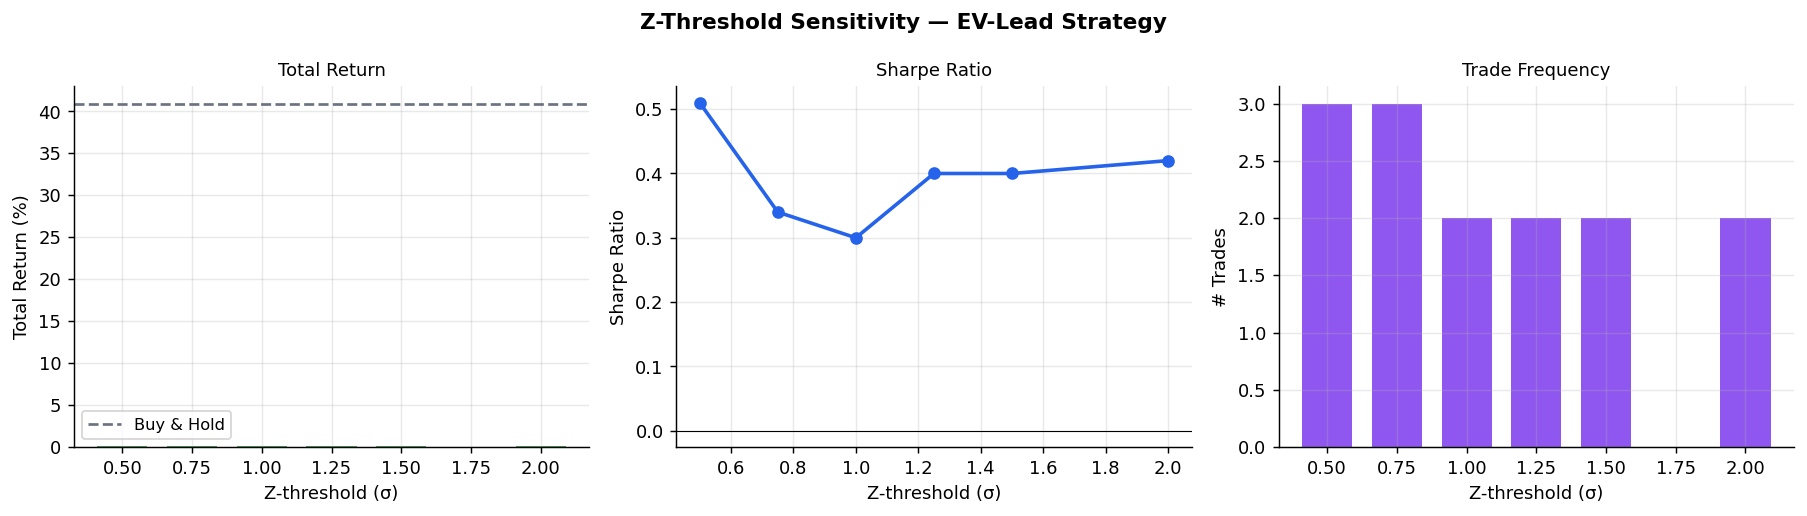

Saved → outputs/backtest_ev_lead_sensitivity.png


In [15]:
# ── Plot 3: Sensitivity ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Z-Threshold Sensitivity — EV-Lead Strategy",
             fontsize=12, fontweight="bold")

zs = sweep_df.index.tolist()

axes[0].bar(zs, sweep_df["Total Return %"], width=0.18,
            color=[P["buy"] if v > 0 else P["sell"]
                   for v in sweep_df["Total Return %"]], alpha=0.85)
axes[0].axhline(sweep_df["B&H Return %"].iloc[0], color=P["bh"],
                lw=1.5, ls="--", label="Buy & Hold")
axes[0].set_xlabel("Z-threshold (σ)", fontsize=10)
axes[0].set_ylabel("Total Return (%)", fontsize=10)
axes[0].set_title("Total Return", fontsize=10)
axes[0].legend(fontsize=9)

axes[1].plot(zs, sweep_df["Sharpe"], marker="o", color=P["equity"],
             lw=2.0, markersize=6)
axes[1].axhline(0, color="black", lw=0.6)
axes[1].set_xlabel("Z-threshold (σ)", fontsize=10)
axes[1].set_ylabel("Sharpe Ratio", fontsize=10)
axes[1].set_title("Sharpe Ratio", fontsize=10)

axes[2].bar(zs, sweep_df["# Trades"], width=0.18,
            color=P["zscore"], alpha=0.85)
axes[2].set_xlabel("Z-threshold (σ)", fontsize=10)
axes[2].set_ylabel("# Trades", fontsize=10)
axes[2].set_title("Trade Frequency", fontsize=10)

plt.tight_layout()
out = OUT_DIR / "backtest_ev_lead_sensitivity.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out.relative_to(DATA_DIR)}")

---
## Better Indicators — Exploiting the 2-Hour Lead Directly

The Z-score signal requires ≥5 historical samples to initialise and normalises against a *rolling gap distribution* — it fires **after** a divergence has already built up.

Since cross-correlation proves EV leads futures by exactly **1 bar = 2 hours**, three more direct signals are available:

| Signal | Formula | Rationale |
|--------|---------|-----------|
| **EV Momentum** | `sign(Δ EV[t])` | EV moving up *now* → futures follow *next bar*. Pure 1-bar lead. |
| **Basis Gap Direction** | `sign(EV[t] − Futures[t])` | EV > Futures → crowd prices higher → futures will converge up. No rolling needed. |
| **Combined (AND)** | Both must agree | Highest conviction: EV is rising *and* already above futures. |

All three naturally embed the lead — the backtester's 1-bar execution lag means the trade opens exactly 2 h after the signal, matching the measured lag.

In [16]:
# ── Build the three improved signals from df_roll ────────────────────────────

# Signal A — EV Momentum: sign of Δ EV over one 2-hour bar
#   +1 if EV went up this bar  (futures expected to follow next bar)
#   -1 if EV went down         (exit / avoid long)
ev_delta       = df_roll["pm_ev"].diff()
sig_momentum   = np.sign(ev_delta).fillna(0).astype(int)

# Signal B — Basis Gap Direction: sign of (EV − Futures)
#   +1 if crowd prices above futures  (futures expected to converge up)
#   -1 if crowd prices below futures  (futures expected to converge down)
sig_basis_dir  = np.sign(df_roll["pm_ev"] - df_roll["nymex"]).astype(int)

# Signal C — Combined AND: both signals must agree on direction
#   +1 only when EV is rising AND EV > futures (highest conviction buy)
#   -1 only when EV is falling AND EV < futures (exit signal)
sig_combined   = sig_momentum.copy()
sig_combined[(sig_momentum != sig_basis_dir)] = 0   # disagree → hold

# ── Run all four signals through the backtester ───────────────────────────────
prices_bt = df_roll["nymex"].rename("close")

results_comp = {}
for label, sig in [
    ("Z-Score (baseline)",    df_roll["signal"]),
    ("EV Momentum",           sig_momentum),
    ("Basis Gap Direction",   sig_basis_dir),
    ("Combined (AND)",        sig_combined),
]:
    r = run_backtest(prices_bt, sig)
    m = r["metrics"]
    trd = pd.DataFrame(r["trades"])
    win_rate = (trd["pnl"] > 0).mean() * 100 if not trd.empty else float("nan")
    results_comp[label] = {
        "Total Return %": m["total_return_pct"],
        "Sharpe":          m["sharpe_ratio"],
        "Max DD %":         m["max_drawdown_pct"],
        "# Trades":         m["n_trades"],
        "Win Rate %":       round(win_rate, 1),
        "equity":           pd.DataFrame(r["equity_curve"])
                              .assign(date=lambda d: pd.to_datetime(d["date"]))
                              .set_index("date")["value"],
    }
    print(f"  {label:<26}  return={m['total_return_pct']:+.2f}%  "
          f"sharpe={m['sharpe_ratio']:.3f}  trades={m['n_trades']}  "
          f"win={win_rate:.0f}%")

# Summary table
comp_df = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if kk != "equity"}
                        for k, v in results_comp.items()}).T
print("\n", comp_df.to_string())


  Z-Score (baseline)          return=+0.10%  sharpe=0.300  trades=2  win=100%
  EV Momentum                 return=+0.06%  sharpe=0.230  trades=71  win=52%
  Basis Gap Direction         return=+0.26%  sharpe=0.590  trades=4  win=75%
  Combined (AND)              return=+0.24%  sharpe=0.560  trades=3  win=67%

                      Total Return %  Sharpe  Max DD %  # Trades  Win Rate %
Z-Score (baseline)             0.10    0.30     -0.39       2.0       100.0
EV Momentum                    0.06    0.23     -0.18      71.0        52.1
Basis Gap Direction            0.26    0.59     -0.49       4.0        75.0
Combined (AND)                 0.24    0.56     -0.48       3.0        66.7


/var/folders/vw/q9zgtmm91l9gnh2y38yghfqr0000gn/T/ipykernel_83715/3803485514.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


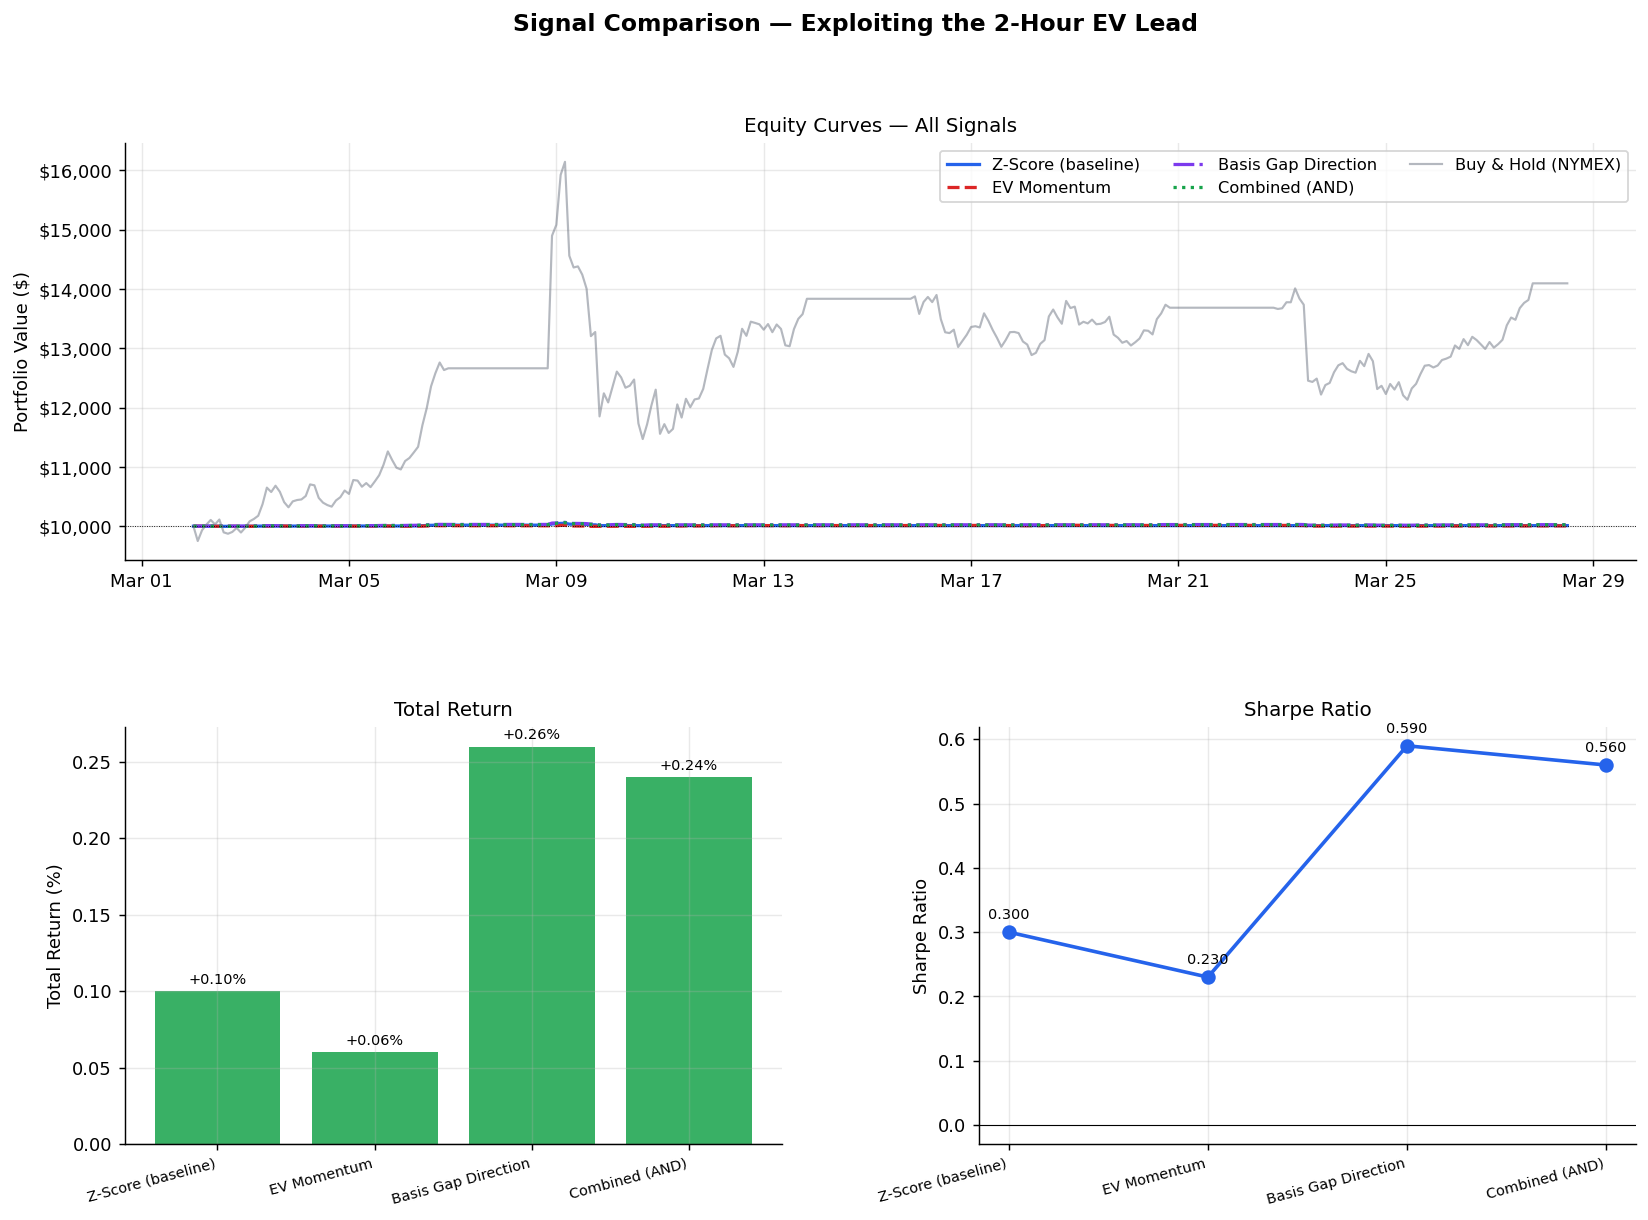

Saved → outputs/backtest_signal_comparison.png


In [17]:
# ── Plot: Equity curves + comparison bar charts ───────────────────────────────
fig = plt.figure(figsize=(15, 10))
gs  = fig.add_gridspec(2, 2, hspace=0.40, wspace=0.30)

ax_eq   = fig.add_subplot(gs[0, :])   # full-width equity curves
ax_ret  = fig.add_subplot(gs[1, 0])
ax_sh   = fig.add_subplot(gs[1, 1])

fig.suptitle("Signal Comparison — Exploiting the 2-Hour EV Lead",
             fontsize=13, fontweight="bold")

# ── Equity curves ─────────────────────────────────────────────────────────────
line_styles = ["-", "--", "-.", ":"]
line_colors = [P["equity"], P["sell"], P["zscore"], P["buy"]]
for (label, data), ls, lc in zip(results_comp.items(), line_styles, line_colors):
    ax_eq.plot(data["equity"].index, data["equity"].values,
               lw=1.8, ls=ls, color=lc, label=label)
ax_eq.plot(bh_curve.index, bh_curve.values,
           lw=1.2, ls="-", color=P["bh"], alpha=0.5, label="Buy & Hold (NYMEX)")
ax_eq.axhline(INITIAL_CAPITAL, color="black", lw=0.5, ls=":")
ax_eq.set_ylabel("Portfolio Value ($)", fontsize=10)
ax_eq.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax_eq.set_title("Equity Curves — All Signals", fontsize=11)
ax_eq.legend(fontsize=9, ncol=3)
ax_eq.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# ── Total Return bars ─────────────────────────────────────────────────────────
labels  = list(results_comp.keys())
returns = [results_comp[l]["Total Return %"] for l in labels]
sharpes = [results_comp[l]["Sharpe"] for l in labels]
bar_c   = [P["buy"] if v >= 0 else P["sell"] for v in returns]

x = range(len(labels))
ax_ret.bar(x, returns, color=bar_c, alpha=0.85)
ax_ret.axhline(0, color="black", lw=0.6)
ax_ret.set_xticks(x)
ax_ret.set_xticklabels(labels, rotation=15, ha="right", fontsize=8)
ax_ret.set_ylabel("Total Return (%)", fontsize=10)
ax_ret.set_title("Total Return", fontsize=11)
for i, v in enumerate(returns):
    ax_ret.text(i, v + (0.005 if v >= 0 else -0.01),
                f"{v:+.2f}%", ha="center", fontsize=8)

ax_sh.plot(x, sharpes, marker="o", color=P["equity"], lw=2.0, markersize=7)
ax_sh.axhline(0, color="black", lw=0.6)
ax_sh.set_xticks(x)
ax_sh.set_xticklabels(labels, rotation=15, ha="right", fontsize=8)
ax_sh.set_ylabel("Sharpe Ratio", fontsize=10)
ax_sh.set_title("Sharpe Ratio", fontsize=11)
for i, v in enumerate(sharpes):
    ax_sh.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=8)

plt.tight_layout()
out = OUT_DIR / "backtest_signal_comparison.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out.relative_to(DATA_DIR)}")


  DIRECT GAP STRATEGY
  Signal       : sign(EV − Futures)
  Total Return : +0.26%
  Buy & Hold   : +40.94%
  Sharpe       : 0.590
  Max Drawdown : -0.49%
  # Trades     : 4
  Win Rate     : 75.0%


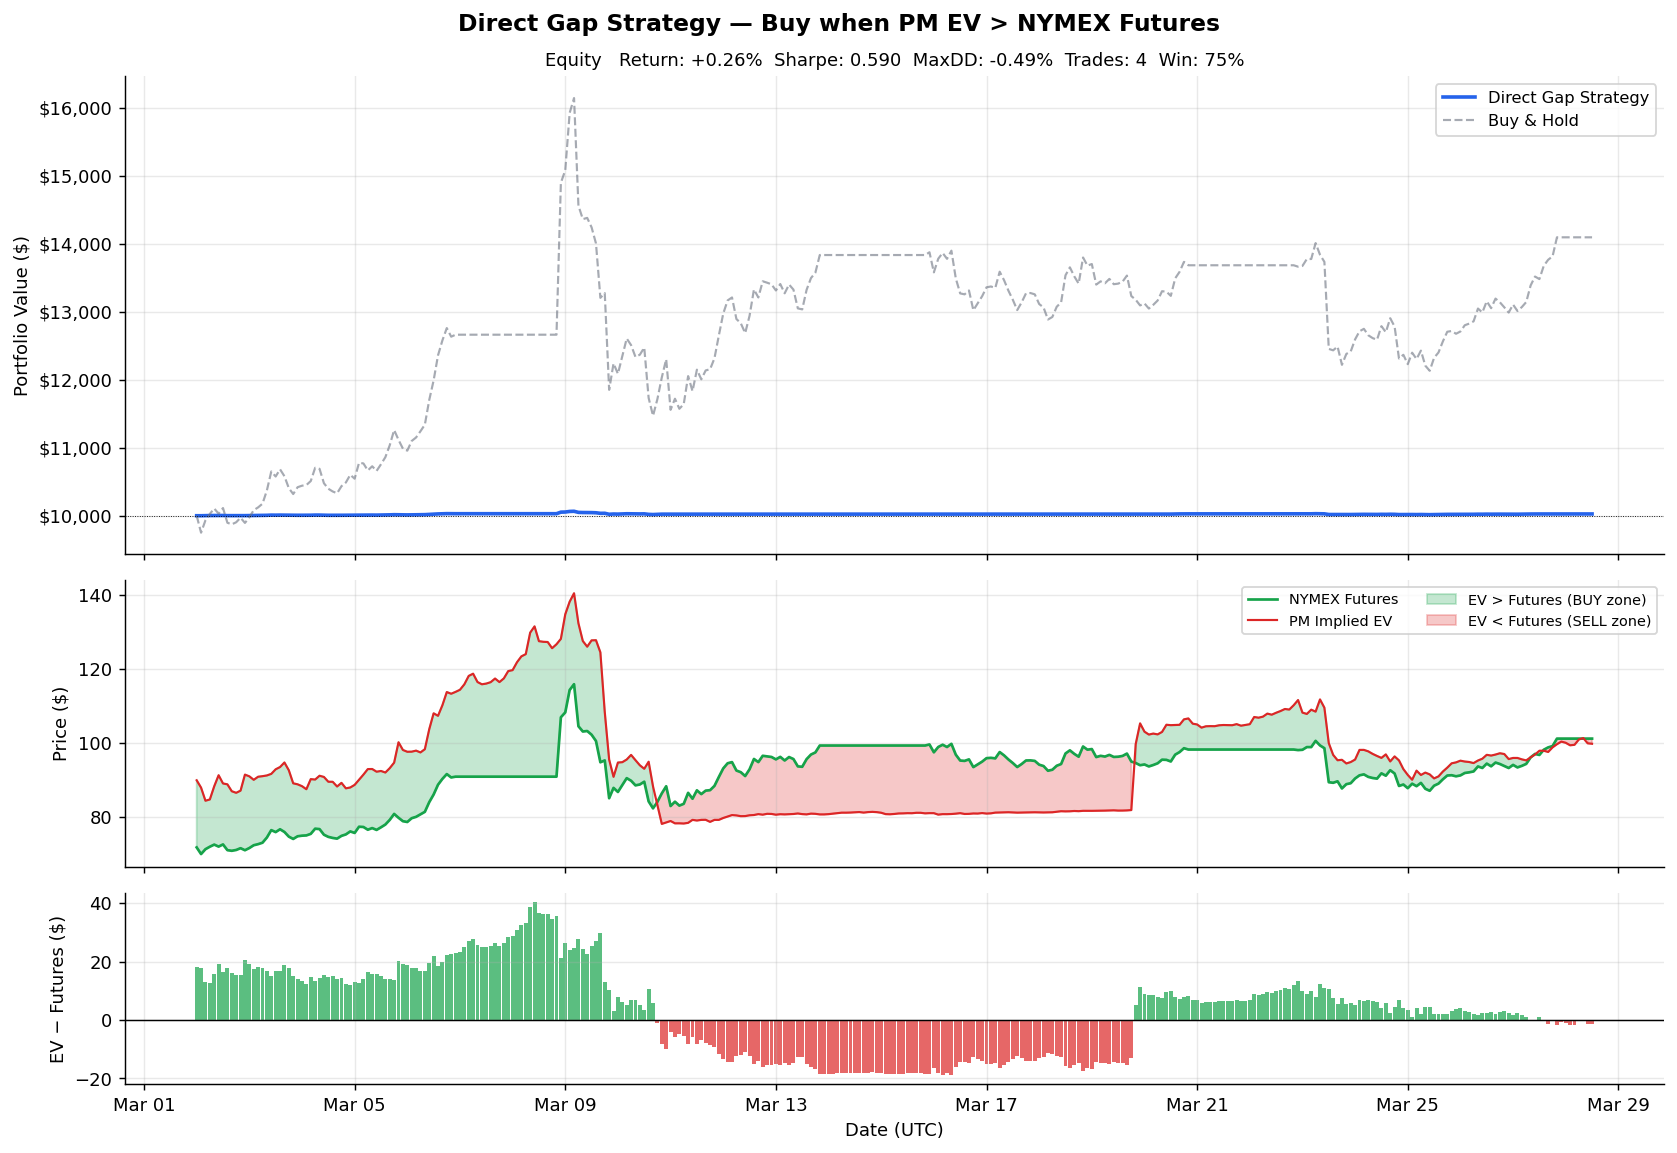

Saved → outputs/backtest_direct_gap.png


In [18]:
# ── Direct Gap Strategy ───────────────────────────────────────────────────────
# Signal: BUY when PM Implied EV > NYMEX Futures (crowd prices above market)
#         SELL (exit) when EV drops below Futures
# Execution lag = 1 bar = 2 h, matching the measured EV lead time.

sig_gap = np.sign(df_roll["pm_ev"] - df_roll["nymex"]).astype(int)

gap_result = run_backtest(df_roll["nymex"].rename("close"), sig_gap)
gap_m      = gap_result["metrics"]
gap_trades = pd.DataFrame(gap_result["trades"])
gap_equity = (pd.DataFrame(gap_result["equity_curve"])
                .assign(date=lambda d: pd.to_datetime(d["date"]))
                .set_index("date")["value"])

win_rate = (gap_trades["pnl"] > 0).mean() * 100 if not gap_trades.empty else float("nan")

print("=" * 48)
print("  DIRECT GAP STRATEGY")
print("=" * 48)
print(f"  Signal       : sign(EV − Futures)")
print(f"  Total Return : {gap_m['total_return_pct']:+.2f}%")
print(f"  Buy & Hold   : {gap_m['buy_hold_return_pct']:+.2f}%")
print(f"  Sharpe       : {gap_m['sharpe_ratio']:.3f}")
print(f"  Max Drawdown : {gap_m['max_drawdown_pct']:.2f}%")
print(f"  # Trades     : {gap_m['n_trades']}")
print(f"  Win Rate     : {win_rate:.1f}%")
print("=" * 48)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True,
                          gridspec_kw={"height_ratios": [2.5, 1.5, 1]})
fig.suptitle("Direct Gap Strategy — Buy when PM EV > NYMEX Futures",
             fontsize=13, fontweight="bold")

# Equity
axes[0].plot(gap_equity.index, gap_equity.values,
             color=P["equity"], lw=2.0, label="Direct Gap Strategy")
axes[0].plot(bh_curve.index, bh_curve.values,
             color=P["bh"], lw=1.2, ls="--", alpha=0.6, label="Buy & Hold")
axes[0].axhline(INITIAL_CAPITAL, color="black", lw=0.5, ls=":")
axes[0].set_ylabel("Portfolio Value ($)", fontsize=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].set_title(f"Equity   Return: {gap_m['total_return_pct']:+.2f}%  "
                  f"Sharpe: {gap_m['sharpe_ratio']:.3f}  "
                  f"MaxDD: {gap_m['max_drawdown_pct']:.2f}%  "
                  f"Trades: {gap_m['n_trades']}  Win: {win_rate:.0f}%", fontsize=10)
axes[0].legend(fontsize=9)

# EV vs Futures with gap shading
axes[1].plot(df_roll.index, df_roll["nymex"], color=P["futures"], lw=1.5, label="NYMEX Futures")
axes[1].plot(df_roll.index, df_roll["pm_ev"],  color=P["ev"],      lw=1.2, label="PM Implied EV")
axes[1].fill_between(df_roll.index, df_roll["pm_ev"], df_roll["nymex"],
                     where=(df_roll["pm_ev"] > df_roll["nymex"]),
                     alpha=0.25, color=P["buy"],  label="EV > Futures (BUY zone)")
axes[1].fill_between(df_roll.index, df_roll["pm_ev"], df_roll["nymex"],
                     where=(df_roll["pm_ev"] < df_roll["nymex"]),
                     alpha=0.25, color=P["sell"], label="EV < Futures (SELL zone)")
axes[1].set_ylabel("Price ($)", fontsize=10)
axes[1].legend(fontsize=8, ncol=2)

# Raw gap
gap_series = df_roll["pm_ev"] - df_roll["nymex"]
axes[2].bar(df_roll.index, gap_series,
            color=[P["buy"] if v > 0 else P["sell"] for v in gap_series],
            alpha=0.7, width=pd.Timedelta("1.8h"))
axes[2].axhline(0, color="black", lw=0.8)
axes[2].set_ylabel("EV − Futures ($)", fontsize=10)
axes[2].set_xlabel("Date (UTC)", fontsize=10)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

plt.tight_layout()
out = OUT_DIR / "backtest_direct_gap.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out.relative_to(DATA_DIR)}")
